In [67]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from tqdm import tqdm
from numba import njit

In [36]:
J = 1
@njit
def Nsy_state(N,p):
    psi = np.ones(N, dtype=np.int64)
    for i in range(N):
        if np.random.random() < p:
            psi[i] = -1
    return psi

def syndrome_calc(psi):
	syndr_arr = []
	for i in range(0, len_psi - 1):
		syndr_arr.append(psi[i]*psi[i+1])
	return syndr_arr
@njit
def s_i(psi_m, psi_p):
	return psi_m*psi_p
@njit
def DecodeStep(i, psi, N_s):
    left  = (i - 1) % N_s
    right = (i + 1) % N_s
    DE_i  = 2 * J * (s_i(psi[left], psi[i]) + s_i(psi[i], psi[right]))
    if DE_i < 0:
        psi[i] *= -1
    elif DE_i == 0:
        if np.random.rand() < 0.5:
            psi[i] *= -1
    return psi
@njit
def FullEvol(L, p):
    psi = Nsy_state(L,p)
    nit = 0
    psi_d = psi.copy()
    while (np.abs(np.sum(psi_d)) != L):
        for _ in range(L):
            i = np.random.randint(0,L)
            psi_i = DecodeStep(i, psi_d, L)
            psi_d = psi_i
    return psi_d


In [37]:
def Noise_analysis(L_arr, p_arr):
    trials = 1000 
    flogical_arr = {L: [] for L in L_arr}
    SE_arr = {L: [] for L in L_arr}

    for L_i in L_arr:
        for p_i in p_arr:
            logical_fail = 0 
            convergence_fail = 0
            for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
                state_f = FullEvol(L_i, p_i)
                if np.sum(state_f)/len(state_f) != 1:
                    logical_fail  += 1
            lfp = logical_fail/trials 
            SE = np.sqrt(lfp*(1-lfp)/trials)
            flogical_arr[L_i].append(lfp)
            SE_arr[L_i].append(SE)
    return flogical_arr, SE_arr

In [55]:
p_arr = np.linspace(0,1,20)
L_arr = [20,50,100]
flogical, SE_arr = Noise_analysis(L_arr,p_arr)

L=100, p=1.00: 100%|██████████| 1000/1000 [00:00<00:00, 35900.30it/s]


In [56]:
slope1, intercept1 = np.polyfit(p_arr, flogical[L_arr[0]], deg=1)
slope2, intercept2 = np.polyfit(p_arr, flogical[L_arr[1]], deg=1)
slope3, intercept3 = np.polyfit(p_arr, flogical[L_arr[2]], deg=1)

print(slope1)
print(slope2)
print(slope3)

0.9988285714285717
1.0
0.9963571428571428


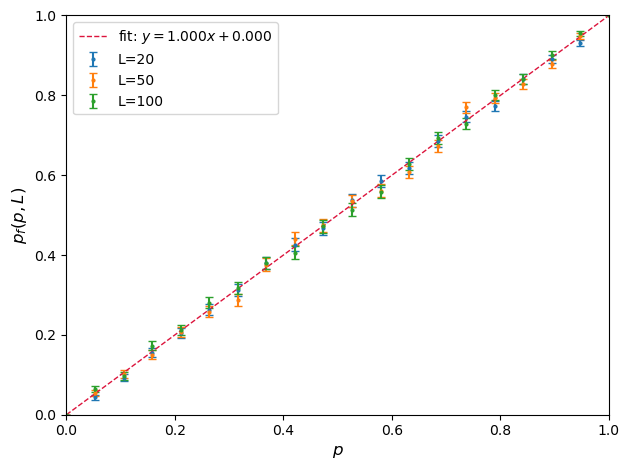

In [87]:
def linear(x, a, b):
    return a * x + b

y =  flogical[L_arr[2]]
x = p_arr
se_clipped = np.clip(SE_arr[L_arr[2]], 1e-6, None)
popt, pcov = curve_fit(linear, x, y, sigma=se_clipped , absolute_sigma=True)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = linear(x_fit, a, b)

for L in L_arr:
    plt.errorbar(p_arr,flogical[L],yerr = SE_arr[L], fmt='o',markersize =2, capsize=3, label = f"L={L}")
    #plt.errorbar(x_all, y_all, yerr=y_err_all, fmt='o', capsize=4,color='steelblue', label='data')
    
plt.plot(x_fit, y_fit, color='crimson', linestyle = '--', linewidth=1.0, label=f'fit: $y = {a:.3f}x + {b:.3f}$')

plt.xlabel("$p$", fontsize = 12)
plt.ylabel("$p_f (p,L)$", fontsize = 12)
plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.savefig("1DIsing.png")
plt.show()

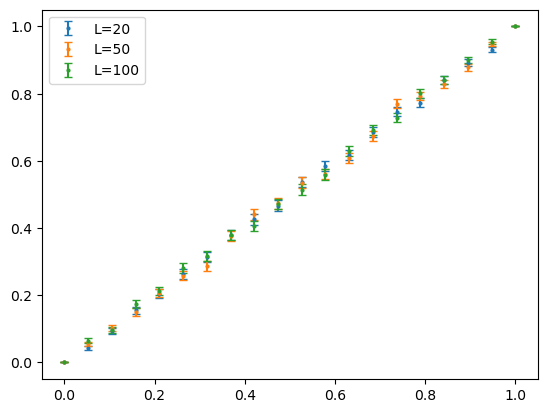

In [57]:
plt.figure()
for L in L_arr:
    plt.errorbar(p_arr,flogical[L],yerr = SE_arr[L], fmt='o',markersize =2, capsize=3, label = f"L={L}")
plt.legend()
plt.show()

In [ ]:
rows_data = []
for L in L_arr:
    for i in range(len(p_arr)):
        dict = {'p': p_arr[i], 'L': L, 'pf': flogical_arr[L][i], 'SE':SE_arr[L][i]}
        rows_data.append(dict)
df = pd.DataFrame(rows_data)
print(df)

df.to_csv('Ising1DData.csv', index= False)